In [1]:
%matplotlib inline
import os
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import palettable as pltt

In [2]:
df1 = pd.read_csv("data/shrug-vd11-csv/pc11_vd_clean_pc11subdist.csv")

In [3]:
df2 = pd.read_csv("data/shrug-ec13-csv/ec13_pc11subdist.csv")

In [4]:
pc11 = df1.loc[:,['pc11_state_id', 'pc11_district_id', 'pc11_subdistrict_id','pc11_vd_mcw_cntr']]

In [5]:
ec13 = df2.loc[:,['pc11_subdistrict_id','ec13_emp_all','ec13_emp_f','ec13_emp_m']]

In [6]:
gdf = gpd.read_file("data/shrug-pc11subdist-poly-shp/subdistrict.shp")

In [7]:
gdf.columns

Index(['pc11_s_id', 'pc11_d_id', 'pc11_sd_id', 'sd_name', 'geometry'], dtype='object')

In [8]:
gdf.pc11_sd_id = gdf.pc11_sd_id.astype('int64')

In [9]:
pc11.rename(columns={'pc11_state_id':'pc11_s_id',
                     'pc11_district_id':'pc11_d_id',
                     'pc11_subdistrict_id':'pc11_sd_id'}, 
            inplace=True)

In [10]:
ec13.rename(columns={'pc11_subdistrict_id':'pc11_sd_id'}, inplace = True)

In [11]:
gdf.drop(['pc11_s_id','pc11_d_id'], axis=1, inplace=True)

In [12]:
geo_temp = gdf.merge(pc11, on="pc11_sd_id")
geo_temp.head()

,pc11_sd_id,sd_name,geometry,pc11_s_id,pc11_d_id,pc11_vd_mcw_cntr
0,3722,Lakhpat,"MULTIPOLYGON (((68.39398 23.44476, 68.39264 23...",24,468,3.0
1,3723,Rapar,"MULTIPOLYGON (((70.5344 23.46489, 70.53222 23....",24,468,12.0
2,3724,Bhachau,"MULTIPOLYGON (((70.45008 23.01226, 70.44904 23...",24,468,1.0
3,3725,Anjar,"POLYGON ((70.23631 23.40849, 70.23631 23.40545...",24,468,18.0
4,3726,Bhuj,"POLYGON ((69.78433 23.9911, 69.79143 23.9875, ...",24,468,10.0


In [13]:
geo = geo_temp.merge(ec13, on="pc11_sd_id")
geo.head()

,pc11_sd_id,sd_name,geometry,pc11_s_id,pc11_d_id,pc11_vd_mcw_cntr,ec13_emp_all,ec13_emp_f,ec13_emp_m
0,3722,Lakhpat,"MULTIPOLYGON (((68.39398 23.44476, 68.39264 23...",24,468,3.0,7323.000000,582.000000,6741.000000
1,3723,Rapar,"MULTIPOLYGON (((70.5344 23.46489, 70.53222 23....",24,468,12.0,7806.000000,1436.000000,6370.000000
2,3724,Bhachau,"MULTIPOLYGON (((70.45008 23.01226, 70.44904 23...",24,468,1.0,25000.561281,3790.480790,21210.080491
3,3725,Anjar,"POLYGON ((70.23631 23.40849, 70.23631 23.40545...",24,468,18.0,31652.953489,4799.088741,26853.864749
4,3726,Bhuj,"POLYGON ((69.78433 23.9911, 69.79143 23.9875, ...",24,468,10.0,59569.295016,9031.647966,50537.647050


In [14]:
geo["ratio"] = geo.ec13_emp_f/geo.ec13_emp_m

In [15]:
high_employment = geo.loc[geo.ratio > 0,:].sort_values("ratio",ascending=False).head(1000)
higher_share = geo.loc[geo.ec13_emp_f > geo.ec13_emp_m,:]

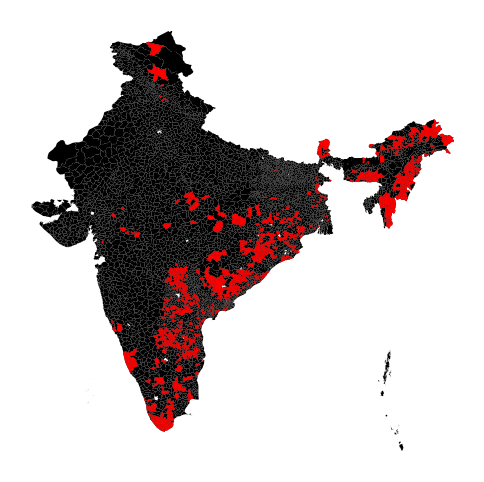

In [16]:
f, ax = plt.subplots(1, figsize=(6, 6))
# Base layer with all the areas for the background
geo.plot(facecolor="black", linewidth=0.025, ax=ax)
high_employment.plot(alpha=1, facecolor="red", linewidth=0, ax=ax)
ax.set_axis_off()
plt.axis("equal")
plt.show()

In [17]:
access = geo.sort_values('pc11_vd_mcw_cntr').head(2500)

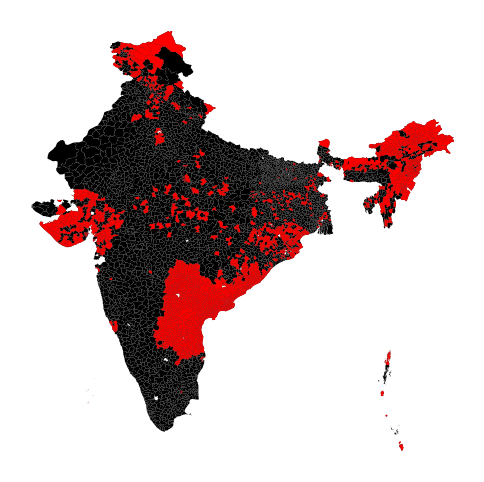

In [18]:
f, ax = plt.subplots(1, figsize=(6, 6))
# Base layer with all the areas for the background
geo.plot(facecolor="black", linewidth=0.025, ax=ax)
access.plot(alpha=1, facecolor="red", linewidth=0, ax=ax)
ax.set_axis_off()
plt.axis("equal")
plt.show()

In [19]:
import osmnx as ox

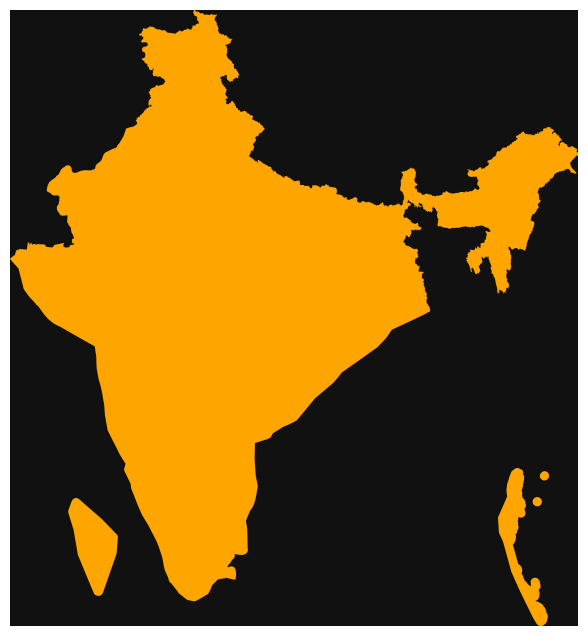

In [20]:
country = ox.geocode_to_gdf("India")
country = ox.projection.project_gdf(country)
fig, ax = ox.plot_footprints(country)

In [21]:
country.columns

Index(['geometry', 'bbox_north', 'bbox_south', 'bbox_east', 'bbox_west',
       'place_id', 'osm_type', 'osm_id', 'lat', 'lon', 'class', 'type',
       'place_rank', 'importance', 'addresstype', 'name', 'display_name'],
      dtype='object')

In [22]:
gdf = geo[geo.pc11_s_id == 23]

# Step 2: Get the boundary of your area (assuming gdf is a polygon)
# If your GeoDataFrame has multiple features, you might want to take the union of all geometries.
boundary = gdf.union_all()  # Use unary_union to merge if multiple features

# Step 3: Query OSM data for water bodies (lakes, rivers, reservoirs)
# The key for water bodies in OSM is 'water' (e.g., 'lake', 'river', 'reservoir', etc.)
# You can also filter for specific water types if necessary
tags = {"water":"lake"}

# Download the water bodies within the boundary of the area
water_gdf = ox.features_from_polygon(boundary, tags)



C:\Users\adell\miniconda3\envs\gds24\lib\site-packages\osmnx\_overpass.py:254: UserWarning: This area is 161 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


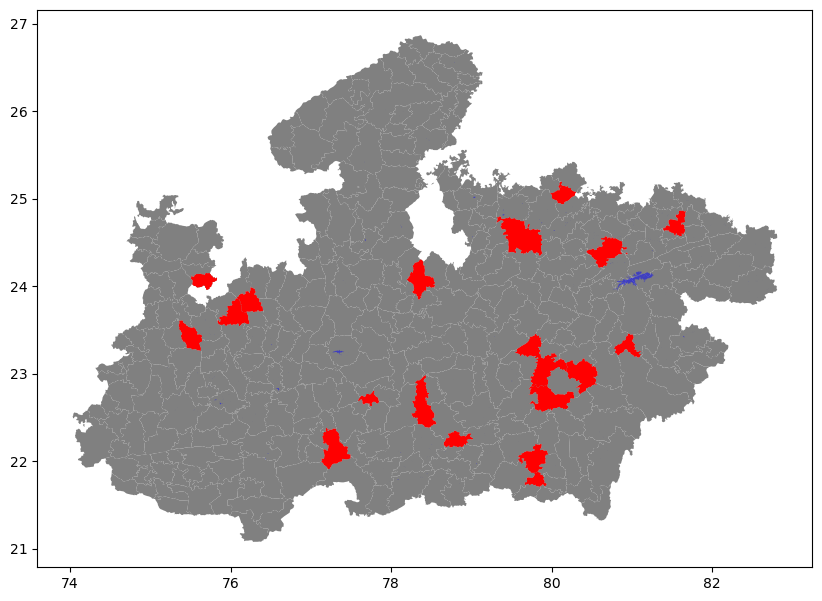

In [23]:
access = gdf.sort_values('pc11_vd_mcw_cntr').head(20)

# Step 4: Plot the results (optional)
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color="grey")  # Plot your area
water_gdf.plot(ax=ax, color='blue', alpha=0.5)  # Plot water bodies
access.plot(alpha=1, facecolor="red", linewidth=0, ax=ax)
plt.show()

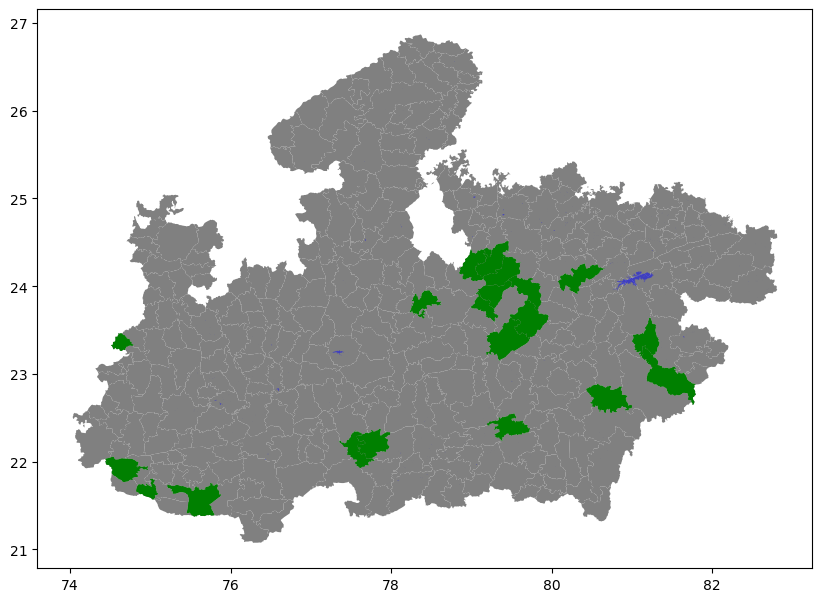

In [24]:
high_employment = gdf.loc[geo.ratio > 0,:].sort_values("ratio",ascending=False).head(20)

# Step 4: Plot the results (optional)
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color="grey")  # Plot your area
high_employment.plot(alpha=1, facecolor="green", linewidth=0, ax=ax)
water_gdf.plot(ax=ax, color='blue', alpha=0.5)  # Plot water bodies
plt.show()

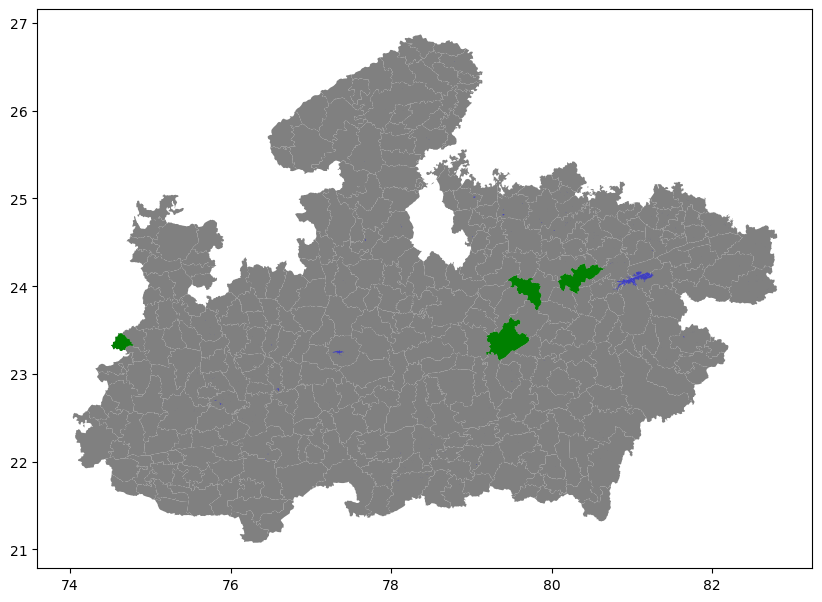

In [25]:
higher_share = gdf.loc[gdf.ec13_emp_f > gdf.ec13_emp_m,:]

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color="grey")  # Plot your area
higher_share.plot(alpha=1, facecolor="green", linewidth=0, ax=ax)
water_gdf.plot(ax=ax, color='blue', alpha=0.5)  # Plot water bodies
plt.show()

In [26]:
geo.pc11_s_id.unique()

array([24, 21, 22, 23,  2,  3,  4,  5,  6,  7,  8,  9, 10, 19, 20,  1, 11,
       12, 13, 14, 15, 16, 17, 18, 25, 26, 27, 28, 29, 30, 32, 33, 34, 31,
       35], dtype=int64)